# Churn Prediction — Modeling & Evaluation 

## Objectives 
In this notebook I train and evaluate two classification models on the processed data from `02_feature_engineering.ipynb`: Logistic Regression as the baseline model and Random Forest to capture any non-linear relationships. I use cross-validation to ensure evaluation reliability, and `GridSearchCV` for hyperparameter tuning. Model performance is evaluated using accuracy, recall, F1-score, and AUC-ROC — with an emphasis on recall since false negatives (missed churners) are more costly to the business than false positives. Finally, I apply segmentation analysis on `Contract` type to verify model reliability across different customer groups — contract type is an actionable variable the business can directly influence to reduce churn. 

## Output 
- Trained Logistic Regression and Random Forest models 
- Recommended model with performance metrics 
- Justification for model choice and business relevance 
- Visualizations for README

## 3.1 Setup & Imports

Importing most of the same libraries and absolute paths like numpy, pandas, and `X` and `y` train/test paths. Addition of sklearn model libraries for Logistic Regression, Random Forest GridSearch, cross-validation, evaluation metrics, as well as graphing libraries for README visualization. 

In [1]:
import warnings
warnings.filterwarnings('ignore') # suppress sklearn warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# modeling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score

# evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import RocCurveDisplay


RANDOM_STATE = 42
X_TRAIN_PATH = '../data/processed/X_train.csv'
X_TEST_PATH = '../data/processed/X_test.csv'
Y_TRAIN_PATH = '../data/processed/y_train.csv'
Y_TEST_PATH = '../data/processed/y_test.csv'

## 3.2 Load Processed Data

Loading the four processed datasets saved from `02_feature_engineering.ipynb` using the path constants defined in `3.1`. `.squeeze()` is applied to `y_train` and `y_test` to convert them from single-column DataFrames to 1D Series, which is the format `sklearn` models expect for target variables.

In [2]:
X_train = pd.read_csv(X_TRAIN_PATH)
X_test = pd.read_csv(X_TEST_PATH)
y_train = pd.read_csv(Y_TRAIN_PATH).squeeze()
y_test = pd.read_csv(Y_TEST_PATH).squeeze()

In [4]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 22), (1409, 22), (5634,), (1409,))

`.shape` confirms the four datasets were loaded correctly — `X_train` (5634, 22), `X_test` (1409, 22), `y_train` (5634,), `y_test` (1409,) — matching the expected shapes from `02_feature_engineering.ipynb` and confirming 1D target Series after `.squeeze()`. 

## 3.3 Baseline Model — Logistic Regression

I implement Logistic Regression as the baseline model using `sklearn`'s `LogisticRegression`. This is an appropriate baseline because it models the linear relationship between features and the log-odds of the target, is highly interpretable, and serves as a strong reference point before introducing more complex models like Random Forest. The model is fit on `X_train` and `y_train`, then used to generate both class predictions and probability scores for AUC-ROC evaluation. `random_state=RANDOM_STATE` ensures reproducibility and `class_weight='balanced'` handles the class imbalance identified in EDA (73.5%/26.5%) by adjusting weights inversely proportional to class frequency so the minority class (`Churn=1`) gets more weight during training.

In [3]:
# create logistic regression
lr = LogisticRegression(random_state= RANDOM_STATE, class_weight='balanced')
# fit
lr.fit(X_train, y_train)
# predict
y_pred_lr = lr.predict(X_test)
y_pred_proba_lr = lr.predict_proba(X_test)[:,1] # [:,1] selects probability of class 1 (Churn=Yes) for AUC-ROC

To evaluate performance I report accuracy, precision, recall, F1-score, and AUC-ROC — with recall on class 1 (`Churn=Yes`) as the most important metric since missing a potential churner is more costly to the business than a false alarm.  I also produce a confusion matrix heatmap to visualize TP, TN, FP, and FN counts directly.

In [4]:
# evaluation metrics
print(classification_report(y_test, y_pred_lr))
print('AUC-ROC score:', roc_auc_score(y_test, y_pred_proba_lr))

              precision    recall  f1-score   support

           0       0.92      0.73      0.82      1036
           1       0.53      0.82      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.76      0.77      1409

AUC-ROC score: 0.8606829732835095


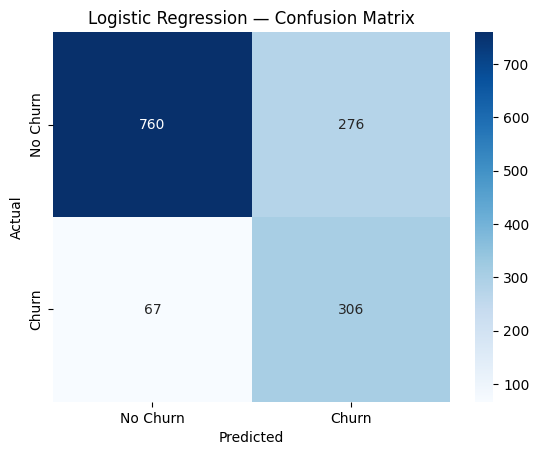

In [5]:
# heatmap confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot = True, fmt = 'd', cmap= 'Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../images/Logistic_Regression_Confusion_Matrix.png', bbox_inches='tight')
plt.show()

Precision of 0.92 for No Churn indicates that of everything predicted as No Churn, 92% were actually non-churners. Precision of 0.53 for Churn indicates that only 53% of predicted churners were actually churners. Recall of 0.73 for No Churn indicates that 73% of actual non-churners were correctly identified — the remaining 27% were incorrectly predicted as Churn (FP). Recall of 0.82 for Churn indicates that 82% of actual churners were correctly identified — the remaining 18% were incorrectly predicted as No Churn (FN).
 
F1-score of 0.82 for No Churn and 0.64 for Churn represents the harmonic mean of precision and recall for each class. Accuracy of 0.76 indicates the model correctly classifies 76% of all customers. AUC-ROC of 0.86 indicates strong discriminative ability between the two classes. 

The confusion matrix shows TN: 760, FP: 276, FN: 67, TP: 306. FP: 276 lowers No Churn recall and Churn precision. FN: 67 lowers Churn recall and No Churn precision. TP: 306 drives Churn precision and recall up. TN: 760 drives No Churn precision and recall up. 

Overall the baseline Logistic Regression shows decent recall for Churn (0.82) — catching most actual churners — but poor precision (0.53), indicating it frequently misclassifies non-churners as churners. The AUC-ROC of 0.86 suggests strong discriminative ability. The F1-score of 0.64 for Churn reflects the precision/recall tradeoff introduced by `class_weight='balanced'`. Random Forest will be evaluated next to see if it improves this balance.

## 3.4 Random Forest Model

In addition to the baseline model, I implement Random Forest to capture any non-linear relationships Logistic Regression may have missed — such as the relationship between `tenure` and `Churn` and `MonthlyCharges` and `Churn`, both of which showed non-normal distributions in EDA. I initialize with `n_estimators=100` as a standard starting point before tuning, set `random_state=RANDOM_STATE` for reproducibility, and `class_weight='balanced'` to handle class imbalance consistently with the baseline model.

In [6]:
# create Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state= RANDOM_STATE, class_weight='balanced')
# fit
rf.fit(X_train, y_train)
# predict
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:,1] # [:,1] selects probability of class 1 (Churn=Yes) for AUC-ROC

Evaluation follows the same approach as Logistic Regression — accuracy, precision, recall, F1-score, AUC-ROC, and a confusion matrix heatmap — with recall on class 1 (`Churn=Yes`) remaining the most important metric.

In [7]:
# evaluation metrics
print(classification_report(y_test, y_pred_rf))
print('AUC-ROC score:', roc_auc_score(y_test, y_pred_proba_rf))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1036
           1       0.56      0.64      0.60       373

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.78      1409

AUC-ROC score: 0.8313786785636652


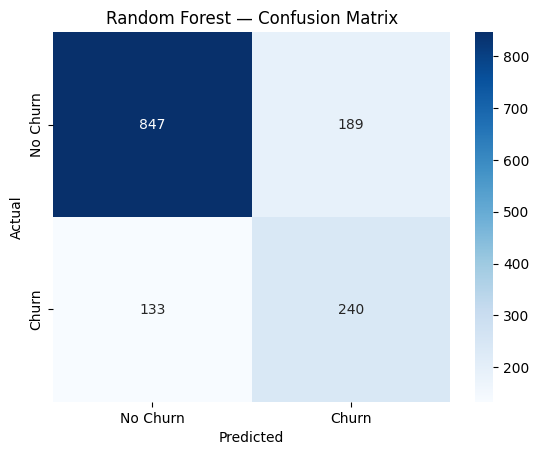

In [8]:
# heatmap confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot = True, fmt = 'd', cmap= 'Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../images/Random_Forest_Confusion_Matrix.png', bbox_inches='tight')
plt.show()

Precision of 0.86 for No Churn indicates that 86% of predicted No Churn instances were actually non-churners. Precision of 0.56 for Churn indicates that only 56% of predicted churners were actually churners. Recall of 0.82 for No Churn indicates 82% of actual non-churners were correctly identified — the remaining were incorrectly predicted as Churn (FP). Recall of 0.64 for Churn indicates only 64% of actual churners were correctly identified — the remaining 36% were incorrectly predicted as No Churn (FN). 

F1-score of 0.84 for No Churn and 0.60 for Churn represents the harmonic mean of precision and recall for each class. Accuracy of 0.77 indicates the model correctly classifies 77% of all customers. AUC-ROC of 0.83 indicates reasonable discriminative ability between the two classes. 

The confusion matrix shows TN: 847, FP: 189, FN: 133, TP: 240. FP: 189 lowers No Churn recall and Churn precision. FN: 133 lowers Churn recall and No Churn precision. TP: 240 drives Churn precision and recall up. TN: 847 drives No Churn precision and recall up. 

Overall, Random Forest outperformed Logistic Regression on Churn precision (0.56 vs 0.53), No Churn recall (0.82 vs 0.73), No Churn F1-score (0.84 vs 0.82), and accuracy (0.77 vs 0.76). However, Logistic Regression outperformed on Churn recall (0.82 vs 0.64) and AUC-ROC (0.86 vs 0.83). Since Churn recall is the most important metric for this task, Logistic Regression is the stronger baseline. Both models will be tuned via `GridSearchCV` to determine whether Random Forest can close the gap — the final recommendation will be based on tuned performance rather than baseline alone.

## 3.5 GridSearchCV 

I use `GridSearchCV` with 5-fold cross-validation to search for the optimal hyperparameters for each model, optimizing for recall on the positive class (`Churn=1`). For the baseline model I tune `C` — higher = less regularization, lower = more regularization — to prevent overfitting so that the model generalizes better, and `solver` — `lbfgs` and `liblinear` since they both work well for small to medium size datasets — to improve optimization. For Random Forest I  tune `n_estimators` since more trees can allow for better classification ability, `max_depth` to prevent overfitting, and `min_samples_leaf` to specify te minimum samples at a leaf node .

In [9]:
# parameters for Logistic Regression to tune
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

# parameters for Random Forest to tune
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

# Logistic Regression tuning
lr_grid_search = GridSearchCV(estimator=lr, param_grid=lr_param_grid, cv=5, scoring='recall', n_jobs=-1)
lr_grid_search.fit(X_train, y_train)


# Random Forest tuning
rf_grid_search = GridSearchCV(estimator=rf, param_grid=rf_param_grid, cv=5, scoring='recall', n_jobs=-1)
rf_grid_search.fit(X_train, y_train)

print('Logistic Regression best params:', lr_grid_search.best_params_)
print('Logistic Regression best recall:', lr_grid_search.best_score_)
print('Random Forest best params:', rf_grid_search.best_params_)
print('Random Forest best recall:', rf_grid_search.best_score_)

Logistic Regression best params: {'C': 1, 'solver': 'lbfgs'}
Logistic Regression best recall: 0.7894492753623188
Random Forest best params: {'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 100}
Random Forest best recall: 0.8061694537346711


Random Forest's cross-validted recall (0.806) is higher than Logistic Regression's (0.789) which suggests Random Forest might turn out to be the better model after tuning. The best parameters found were: Logistic Regression — `C=1, solver='lbfgs'`; Random Forest — `max_depth=5, min_samples_leaf=4, n_estimators=100`. However, these are cross-validated scores on the training data. To get real performance numbers I need to evaluate the tuned models on `X_test`.

In [ ]:
# best models
lr_best = lr_grid_search.best_estimator_
rf_best = rf_grid_search.best_estimator_

# predict on test set lr
y_pred_lr_tuned = lr_best.predict(X_test)
y_pred_proba_lr_tuned = lr_best.predict_proba(X_test)[:, 1]

# predict on test set rf
y_pred_rf_tuned = rf_best.predict(X_test)
y_pred_proba_rf_tuned = rf_best.predict_proba(X_test)[:, 1]


In [12]:
# evaluation for tuned logistic regression
print('Tuned Logistic Regression:')
print(classification_report(y_test, y_pred_lr_tuned))
print('AUC-ROC score:', roc_auc_score(y_test, y_pred_proba_lr_tuned))
# evaluation for tuned random forest
print('Tuned Random Forest:')
print(classification_report(y_test, y_pred_rf_tuned))
print('AUC-ROC score:', roc_auc_score(y_test, y_pred_proba_rf_tuned))


Tuned Logistic Regression:
              precision    recall  f1-score   support

           0       0.92      0.73      0.82      1036
           1       0.53      0.82      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.76      0.77      1409

AUC-ROC score: 0.8606829732835095
Tuned Random Forest:
              precision    recall  f1-score   support

           0       0.93      0.72      0.81      1036
           1       0.52      0.84      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.75      0.76      1409

AUC-ROC score: 0.8619859326963883
